<a href="https://colab.research.google.com/github/Nihalht/quamtum-lab-pr/blob/main/Copy_of_lab_prs_quantumn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import cmath

a = 1
b = 4
c = 2

ans1 = (-b-cmath.sqrt((b**2) - (4 * a*c)))/(2 * a)
ans2 = (-b + cmath.sqrt((b**2) - (4 * a*c)))/(2 * a)

print('The roots are: ',ans1 , ans2)

The roots are:  (-3.414213562373095+0j) (-0.5857864376269049+0j)


In [22]:
import numpy as np

vector_a = np.array([1, 2, 3])
vector_b = np.array([4, 5, 6])

dot_product = np.dot(vector_a, vector_b)

print("Vector a:", vector_a)
print("Vector b:", vector_b)
print("Dot Product:", dot_product)

Vector a: [1 2 3]
Vector b: [4 5 6]
Dot Product: 32


# Quantum Computing Lab Course Codebook
This notebook contains the practical implementations mapped to your course syllabus.

In [23]:
# P1: Quantum Computing Lab Environment Setup & Qiskit Installation
# Install the necessary Qiskit packages
!pip install qiskit qiskit-aer matplotlib pylatexenc

## P2 & P3: Introduction to Qubits, Single-Qubit Gates (X, Y, Z Gates), and Bloch Sphere Visualization

Statevector after applying X gate:
 Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


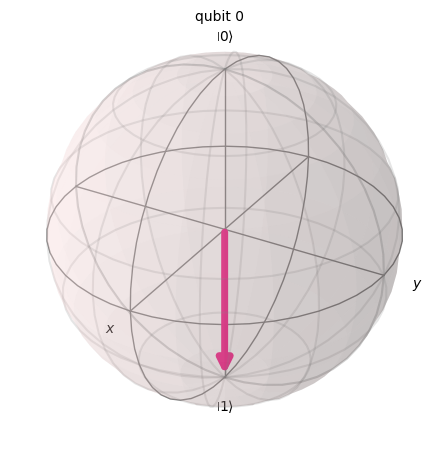

In [24]:
# P2 & P3 Program
import qiskit
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector
from qiskit_aer import AerSimulator

# 1. Create a quantum circuit with 1 qubit
qc = QuantumCircuit(1)

# Apply X gate (NOT gate), Y gate, and Z gate as needed
qc.x(0) # Flips state from |0> to |1>

# Use AerSimulator to get the statevector
simulator = AerSimulator(method='statevector')
qc.save_statevector()

# Run the simulation
result = simulator.run(qc).result()
statevector = result.get_statevector()

print("Statevector after applying X gate:\n", statevector)

# Visualize on Bloch Sphere
plot_bloch_multivector(statevector)

## P4 & P5: Bell States - Theory of Entanglement & Qiskit Implementation

Bell State Circuit:


┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1


Measurement Counts: {'11': 491, '00': 533}


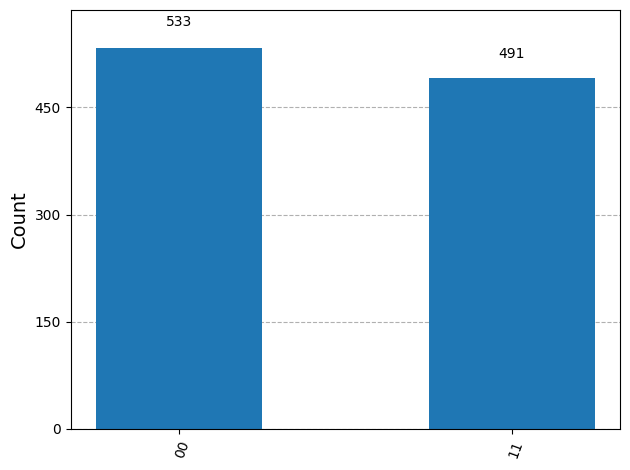

In [25]:
# P4 & P5 Program: Creating a Bell State |Phi+> = (|00> + |11>) / sqrt(2)
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

# Create a circuit with 2 qubits and 2 classical bits
bell_circuit = QuantumCircuit(2, 2)

# 1. Apply a Hadamard gate on qubit 0 to put it in superposition
bell_circuit.h(0)

# 2. Apply a CNOT gate with control qubit 0 and target qubit 1 to entangle them
bell_circuit.cx(0, 1)

# 3. Measure both qubits
bell_circuit.measure([0, 1], [0, 1])

# Draw the circuit
print("Bell State Circuit:")
display(bell_circuit.draw('text'))

# Simulate the circuit execution
simulator = AerSimulator()
transpiled_qc = transpile(bell_circuit, simulator)
job = simulator.run(transpiled_qc, shots=1024)
counts = job.result().get_counts()

print("\nMeasurement Counts:", counts)
plot_histogram(counts)

## P14 & P15: IBM Quantum Hardware Integration and Real Job Submission

In [26]:
# P14 & P15 Program: Simulated / Placeholders for connecting and submitting to IBM Quantum
# (Note: Requires a valid API token from an IBM Quantum account)
!pip install qiskit-ibm-runtime -q
from qiskit_ibm_runtime import QiskitRuntimeService

try:
    # To use real hardware, uncomment the line below and add your token
    # QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="YOUR_IBM_TOKEN", overwrite=True)
    service = QiskitRuntimeService(channel="ibm_quantum_platform")
    print("Successfully connected to IBM Quantum Service!")
    print("Available backends:", service.backends())
except Exception as e:
    print("IBM Quantum credentials not found. Running in offline/simulated mode. Error:", e)

IBM Quantum credentials not found. Running in offline/simulated mode. Error: "Unable to find account. Please make sure an account with the channel name 'ibm_quantum_platform' is saved."


## P16 & P17: Quantum Measurement Principles, Noise Characterization & Error Analysis

In [27]:
# P16 & P17 Program: Simulating a noisy quantum channel (amplitude damping)
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, amplitude_damping_error

# Create noise model
noise_model = NoiseModel()
error = amplitude_damping_error(0.1) # 10% probability of decay

# Apply the 1-qubit error ONLY to 1-qubit instructions like 'h'
noise_model.add_all_qubit_quantum_error(error, ['h'])

# Prepare circuit
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

# Execute with noise model
simulator = AerSimulator(noise_model=noise_model)
transpiled_qc = transpile(qc, simulator)
counts = simulator.run(transpiled_qc, shots=1000).result().get_counts()
print("Noisy counts (deviation from standard 50-50 superposition due to damping):", counts)

Noisy counts (deviation from standard 50-50 superposition due to damping): {'0': 565, '1': 435}


## P18 & P19: Superdense Coding Implementation and Verification

In [28]:
# P18 & P19 Program: Superdense Coding to transmit 2 classical bits ('10') using 1 qubit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2, 2)

# 1. Share entanglement (Bell State)
qc.h(0)
qc.cx(0, 1)
qc.barrier()

# 2. Encode classical message "10"
# To encode "10": apply X gate to the first qubit
qc.x(0)
qc.barrier()

# 3. Decode at Bob's side
qc.cx(0, 1)
qc.h(0)
qc.barrier()

# 4. Measurement
qc.measure([0, 1], [0, 1])

simulator = AerSimulator()
transpiled_qc = transpile(qc, simulator)
counts = simulator.run(transpiled_qc, shots=1024).result().get_counts()
print("Transmitted classical bits decoded by Bob (Expected '10'):", counts)

Transmitted classical bits decoded by Bob (Expected '10'): {'10': 1024}


## P20 & P21: Classical vs Quantum Complexity and Speed-up Analysis

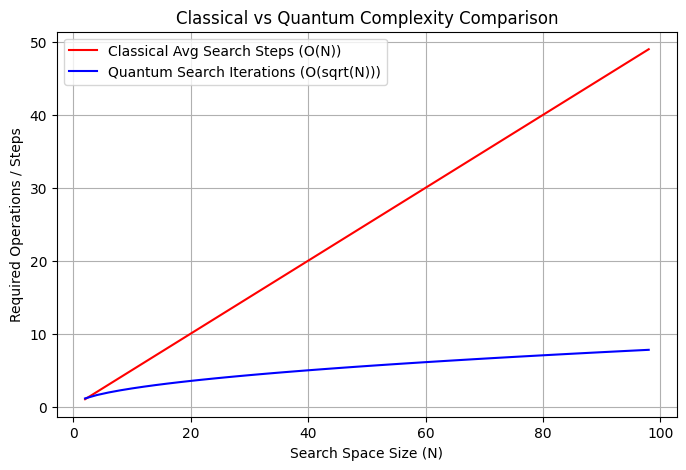

In [29]:
# P20 & P21 Program: Comparison of classical linear search vs quantum Grover search iterations
import matplotlib.pyplot as plt
import numpy as np

N_elements = np.arange(2, 100, 2)
classical_steps = N_elements / 2
quantum_steps = np.sqrt(N_elements) * (np.pi / 4)

plt.figure(figsize=(8, 5))
plt.plot(N_elements, classical_steps, label="Classical Avg Search Steps (O(N))", color='red')
plt.plot(N_elements, quantum_steps, label="Quantum Search Iterations (O(sqrt(N)))", color='blue')
plt.title("Classical vs Quantum Complexity Comparison")
plt.xlabel("Search Space Size (N)")
plt.ylabel("Required Operations / Steps")
plt.legend()
plt.grid(True)
plt.show()

## P22 & P23: Quantum Chemistry Simulation

In [30]:
# P22 & P23 Program: Parametric circuit ansatz representing molecular simulation wavefunction
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import Operator

# 2-qubit ansatz simulating H2 molecular structure
ansatz = TwoLocal(2, 'ry', 'cz', reps=1, entanglement='linear')
ansatz.decompose().draw('text')
print("Ansatz successfully built for Molecular State Simulation.")

Ansatz successfully built for Molecular State Simulation.


/tmp/ipykernel_2004/1701910970.py:6: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(2, 'ry', 'cz', reps=1, entanglement='linear')


## P24 & P25: Quantum Circuit Optimization and Benchmarking

In [31]:
# P24 & P25 Program: Optimizing gate count using Qiskit transpiler passes
from qiskit import QuantumCircuit, transpile
from qiskit.providers.fake_provider import GenericBackendV2

# Unoptimized redundant circuit
qc = QuantumCircuit(1)
qc.x(0)
qc.x(0)  # Redundant self-cancelling NOT gates

backend = GenericBackendV2(num_qubits=2)
optimized_qc = transpile(qc, backend, optimization_level=3)

print("Original depth:", qc.depth(), "gates:", qc.count_ops())
print("Optimized depth (cancels the redundant X gates):", optimized_qc.depth(), "gates:", optimized_qc.count_ops())

Original depth: 2 gates: OrderedDict({'x': 2})
Optimized depth (cancels the redundant X gates): 0 gates: OrderedDict()


## P26 & P27: Hybrid Quantum-Classical Workflows

In [32]:
# P26 & P27 Program: Classical optimization loop for variational quantum circuit (VQE concept)
import numpy as np
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def quantum_energy_evaluation(theta):
    qc = QuantumCircuit(1)
    qc.ry(theta[0], 0)
    qc.save_statevector()

    simulator = AerSimulator(method='statevector')
    result = simulator.run(qc).result()
    sv = result.get_statevector().data
    # Target: minimize the expectation value on Z axis (equivalent to state |1>)
    expected_val = np.real(np.conj(sv[0])*sv[0] - np.conj(sv[1])*sv[1])
    return expected_val

initial_guess = [0.1]
res = minimize(quantum_energy_evaluation, initial_guess, method='COBYLA')
print("Optimized classical parameter (Theta):", res.x)
print("Minimum expectation value reached:", res.fun)

Optimized classical parameter (Theta): [3.1416]
Minimum expectation value reached: -0.999999999973015


## P28, P29 & P30: Quantum Machine Learning (QML) and Mini Project Demonstration

In [33]:
# P28, P29 & P30 Program: Quantum Feature Map and Classifier using variational parameters
from qiskit.circuit.library import ZZFeatureMap

# Create a standard 2-qubit data-encoding feature map for classification tasks
feature_map = ZZFeatureMap(feature_dimension=2, reps=1, entanglement='linear')
print("Quantum Machine Learning Feature Map constructed:")
display(feature_map.decompose().draw('text'))

Quantum Machine Learning Feature Map constructed:


/tmp/ipykernel_2004/3011667521.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=1, entanglement='linear')


┌───┐┌───────────┐                                        
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■──
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├
     └───┘└───────────┘└───┘└────────────────────────────┘└───┘

## P10 & P11: Reversible Computing Fundamentals and Toffoli Gates

In [34]:
# P10 & P11 Program: Toffoli Gate (CCNOT) and Reversible Circuit Testing
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Create a circuit with 3 qubits (control1, control2, target)
reversible_circuit = QuantumCircuit(3, 3)

# 1. Initialize control qubits to |1> (to activate the Toffoli gate)
reversible_circuit.x(0)
reversible_circuit.x(1)

# 2. Apply Toffoli (CCNOT) gate
reversible_circuit.ccx(0, 1, 2)

# 3. Measure all qubits
reversible_circuit.measure([0, 1, 2], [0, 1, 2])

# Draw and run
display(reversible_circuit.draw('text'))
simulator = AerSimulator()
transpiled_qc = transpile(reversible_circuit, simulator)
counts = simulator.run(transpiled_qc, shots=1024).result().get_counts()
print("Reversible Circuit output (Should be '111'):", counts)

┌───┐     ┌─┐      
q_0: ┤ X ├──■──┤M├──────
     ├───┤  │  └╥┘┌─┐   
q_1: ┤ X ├──■───╫─┤M├───
     └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ─────┤ X ├─╫──╫─┤M├
          └───┘ ║  ║ └╥┘
c: 3/═══════════╩══╩══╩═
                0  1  2

Reversible Circuit output (Should be '111'): {'111': 1024}


## P12 & P13: Quantum Teleportation Protocol

In [35]:
# P12 & P13 Program: Quantum Teleportation Protocol
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

teleportation_circuit = QuantumCircuit(3, 3)

# Step 1: Create an arbitrary state to teleport on qubit 0 (e.g., applying X and H)
teleportation_circuit.x(0)
teleportation_circuit.h(0)
teleportation_circuit.barrier()

# Step 2: Create Bell pair between qubit 1 (Alice) and qubit 2 (Bob)
teleportation_circuit.h(1)
teleportation_circuit.cx(1, 2)
teleportation_circuit.barrier()

# Step 3: Alice performs measurements
teleportation_circuit.cx(0, 1)
teleportation_circuit.h(0)
teleportation_circuit.barrier()

# Step 4: Measure qubits 0 and 1
teleportation_circuit.measure(0, 0)
teleportation_circuit.measure(1, 1)
teleportation_circuit.barrier()

# Step 5: Bob applies corrections based on classical bits
teleportation_circuit.cx(1, 2)
teleportation_circuit.cz(0, 2)

# Measure Bob's qubit (qubit 2) to verify
teleportation_circuit.measure(2, 2)

# Draw circuit
display(teleportation_circuit.draw('text'))

┌───┐┌───┐ ░            ░      ┌───┐ ░ ┌─┐    ░            
q_0: ┤ X ├┤ H ├─░────────────░───■──┤ H ├─░─┤M├────░───────■────
     └───┘└───┘ ░ ┌───┐      ░ ┌─┴─┐└───┘ ░ └╥┘┌─┐ ░       │    
q_1: ───────────░─┤ H ├──■───░─┤ X ├──────░──╫─┤M├─░───■───┼────
                ░ └───┘┌─┴─┐ ░ └───┘      ░  ║ └╥┘ ░ ┌─┴─┐ │ ┌─┐
q_2: ───────────░──────┤ X ├─░────────────░──╫──╫──░─┤ X ├─■─┤M├
                ░      └───┘ ░            ░  ║  ║  ░ └───┘   └╥┘
c: 3/════════════════════════════════════════╩══╩═════════════╩═
                                             0  1             2

## P6 & P7: Deutsch-Jozsa Algorithm - Oracle and Circuit Construction
This algorithm determines whether a given function (oracle) is constant or balanced.

In [36]:
# P6 & P7 Program: Deutsch-Jozsa with a balanced 3-qubit oracle
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

n = 3  # Number of input qubits
dj_circuit = QuantumCircuit(n + 1, n)

# 1. Initialize the input qubits to |0> and target qubit (n) to |1>
dj_circuit.x(n)

# 2. Apply Hadamard gates to all qubits
for qubit in range(n + 1):
    dj_circuit.h(qubit)

# 3. Add a Balanced Oracle (e.g., CNOTs controlled by input qubits targeting the last qubit)
dj_circuit.barrier()
for qubit in range(n):
    dj_circuit.cx(qubit, n)
dj_circuit.barrier()

# 4. Apply Hadamard gates to the input qubits
for qubit in range(n):
    dj_circuit.h(qubit)

# 5. Measure the input qubits
for i in range(n):
    dj_circuit.measure(i, i)

# Draw the circuit
display(dj_circuit.draw('text'))

# Run simulation
simulator = AerSimulator()
transpiled_qc = transpile(dj_circuit, simulator)
job = simulator.run(transpiled_qc, shots=1024)
counts = job.result().get_counts()
print("Measurement Result (If '111', the function is balanced):", counts)

┌───┐      ░                 ░ ┌───┐┌─┐      
q_0: ┤ H ├──────░───■─────────────░─┤ H ├┤M├──────
     ├───┤      ░   │             ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├──────░───┼────■────────░─┤ H ├─╫─┤M├───
     ├───┤      ░   │    │        ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├──────░───┼────┼────■───░─┤ H ├─╫──╫─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌─┴─┐┌─┴─┐ ░ └───┘ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├─░─┤ X ├┤ X ├┤ X ├─░───────╫──╫──╫─
     └───┘└───┘ ░ └───┘└───┘└───┘ ░       ║  ║  ║ 
c: 3/═════════════════════════════════════╩══╩══╩═
                                          0  1  2

Measurement Result (If '111', the function is balanced): {'111': 1024}


## P8 & P9: Grover's Search Algorithm - Search Space and Amplitude Amplification

┌───┐ ░     ░ ┌───┐┌───┐   ┌───┐ ░ ┌─┐   
q_0: ┤ H ├─░──■──░─┤ H ├┤ Z ├─■─┤ H ├─░─┤M├───
     ├───┤ ░  │  ░ ├───┤├───┤ │ ├───┤ ░ └╥┘┌─┐
q_1: ┤ H ├─░──■──░─┤ H ├┤ Z ├─■─┤ H ├─░──╫─┤M├
     └───┘ ░     ░ └───┘└───┘   └───┘ ░  ║ └╥┘
c: 2/════════════════════════════════════╩══╩═
                                         0  1

Search Result (Target is '11' with high probability): {'11': 1024}


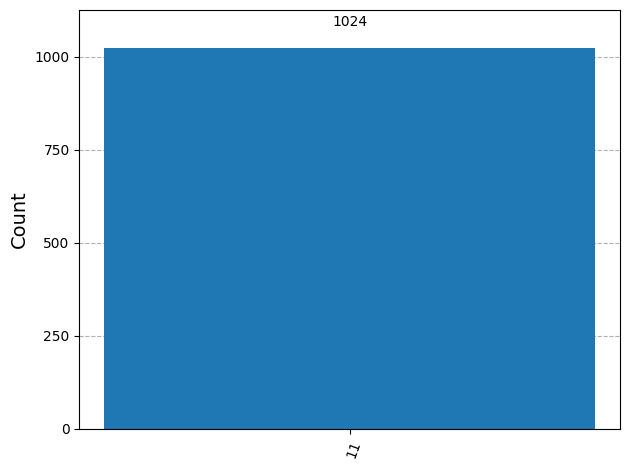

In [37]:
# P8 & P9 Program: 2-Qubit Grover's Search Algorithm searching for state |11>
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Create a circuit with 2 qubits
grover_circuit = QuantumCircuit(2, 2)

# 1. Initialize to superposition
grover_circuit.h([0, 1])
grover_circuit.barrier()

# 2. Oracle for target state |11> (Controlled-Z gate)
grover_circuit.cz(0, 1)
grover_circuit.barrier()

# 3. Diffusion Operator (Amplification)
grover_circuit.h([0, 1])
grover_circuit.z([0, 1])
grover_circuit.cz(0, 1)
grover_circuit.h([0, 1])
grover_circuit.barrier()

# 4. Measurement
grover_circuit.measure([0, 1], [0, 1])

# Draw and run
display(grover_circuit.draw('text'))
simulator = AerSimulator()
transpiled_qc = transpile(grover_circuit, simulator)
counts = simulator.run(transpiled_qc, shots=1024).result().get_counts()
print("Search Result (Target is '11' with high probability):", counts)
plot_histogram(counts)